# Fig. 1: Long-range correlated binary sequences

論文 *Phase-Transition in Binary Sequences with Long-Range Correlations* の図1を再現する。

図1では、履歴依存二値系列の累積和の分散 $D(L)$ を系列長 $L$ で割った

$$
L^{-1}D(L)
$$

を、対数軸上で相関強度 $\mu$ ごとに比較する。論文に合わせて $L_0=100$ とし、
$\mu=-0.8,-0.4,0,0.2,0.5,0.8,0.9$ を使う。実線は解析解、点はMonte Carlo推定である。

## 1. 図1で比較する理論量

長さ $L$ の系列に含まれる1の個数を $k$ とし、0と1の偏りを

$$
x=2k-L
$$

で表す。次の記号が1になる確率は

$$
p(k,L)=\frac12\left(1-\mu\frac{L-2k}{L+L_0}\right)
=\frac12\left(1+\mu\frac{x}{L+L_0}\right).
$$

この履歴依存ランダムウォークの分散を $D(L)=\mathrm{Var}(x)$ とする。Fokker--Planck方程式から、平均が0の場合には

$$
\frac{dD}{dL}=1+\frac{2\mu}{L+L_0}D(L),\qquad D(0)=0
$$

を得る。$\mu\ne1/2$ のとき、積分因子 $(L+L_0)^{-2\mu}$ を使うと

$$
D(L;\mu,L_0)=\frac{L+L_0}{1-2\mu}\left[1-\left(\frac{L_0}{L+L_0}\right)^{1-2\mu}\right].
$$

臨界点 $\mu_c=1/2$ では別途積分し、

$$
D(L;1/2,L_0)=(L+L_0)\log\left(\frac{L+L_0}{L_0}\right)
$$

となる。図1では、この $D(L)$ を $L$ で割って表示する。したがって、$\mu<1/2$ では漸近的に一定、$\mu=1/2$ では $\log L$ に比例し、$\mu>1/2$ では $L^{2\mu-1}$ に比例して増加する。

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

L0 = 100.0
mu_values = [-0.8, -0.4, 0.0, 0.2, 0.5, 0.8, 0.9]
L_values = np.unique(np.round(np.logspace(0, 5, 240)).astype(int))


def theoretical_variance(L, mu, L0=100.0):
    """Equation (5), with the critical expression in equation (6)."""
    L = np.asarray(L, dtype=float)
    if np.isclose(mu, 0.5):
        return (L + L0) * np.log((L + L0) / L0)
    exponent = 1.0 - 2.0 * mu
    return (L + L0) / exponent * (1.0 - (L0 / (L + L0)) ** exponent)


for mu in mu_values:
    assert np.all(theoretical_variance(L_values, mu, L0) >= 0.0)

print(f"L range: {L_values[0]} to {L_values[-1]}")
print(f"L0: {L0}")
print(f"mu values: {mu_values}")

L range: 1 to 100000
L0: 100.0
mu values: [-0.8, -0.4, 0.0, 0.2, 0.5, 0.8, 0.9]


## 2. Monte Carloによる分散推定

各系列について、現在の長さ $L$ と1の個数 $k$ から $p(k,L)$ を計算する。乱数 $u\sim U(0,1)$ に対して $u<p(k,L)$ なら1、それ以外なら0を生成する。

同じ条件で $N$ 本の独立系列を生成し、各 $L$ で

$$
\widehat D(L)=\frac{1}{N-1}\sum_{r=1}^{N}\left(x_r(L)-\bar{x}(L)\right)^2
$$

を計算する。Monte Carlo点は有限本数の系列から得た推定値なので、解析解と完全には一致しない。特に大きな $L$ では、傾向を保ったまま点の揺らぎが見える。

In [ ]:
def simulate_scaled_variance(
    mu,
    L_values,
    L0=100.0,
    n_paths=1000,
    seed=20260906,
):
    """Estimate D(L)/L from independent history-dependent sequences."""
    L_values = np.asarray(L_values, dtype=int)
    max_length = int(L_values.max())
    checkpoints = set(L_values.tolist())
    rng = np.random.default_rng(seed)

    k = np.zeros(n_paths, dtype=np.int64)
    scaled_variance = np.empty(L_values.size, dtype=float)
    checkpoint_index = 0

    for length in range(1, max_length + 1):
        previous_length = length - 1
        x = 2.0 * k - previous_length
        probability_one = 0.5 * (1.0 + mu * x / (previous_length + L0))
        if np.any((probability_one < 0.0) | (probability_one > 1.0)):
            raise ValueError("The transition probability left [0, 1].")

        k += rng.random(n_paths) < probability_one

        if length in checkpoints:
            x = 2.0 * k - length
            scaled_variance[checkpoint_index] = np.var(x, ddof=1) / length
            checkpoint_index += 1

    return scaled_variance


n_paths = 1000
monte_carlo = {
    mu: simulate_scaled_variance(mu, L_values, L0=L0, n_paths=n_paths)
    for mu in mu_values
}

print(f"Generated {n_paths} paths for each of {len(mu_values)} values of mu.")

Generated 1000 paths for each of 7 values of mu.


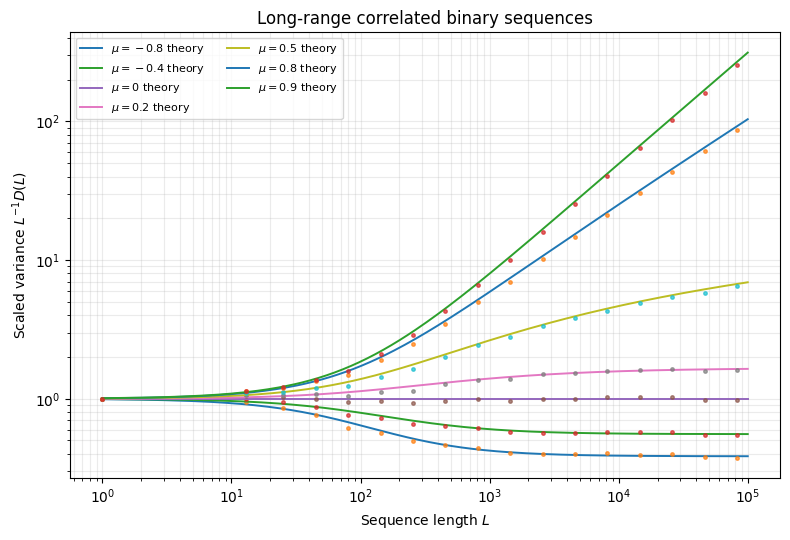

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5.5))

for mu in mu_values:
    theory_scaled = theoretical_variance(L_values, mu, L0) / L_values
    ax.plot(
        L_values,
        theory_scaled,
        linewidth=1.4,
        label=rf"$\mu={mu:g}$ theory",
    )
    ax.plot(
        L_values[::12],
        monte_carlo[mu][::12],
        "o",
        markersize=2.5,
        alpha=0.7,
    )

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Sequence length $L$")
ax.set_ylabel("Scaled variance $L^{-1}D(L)$")
ax.set_title("Long-range correlated binary sequences")
ax.grid(True, which="both", alpha=0.25)
ax.legend(ncol=2, fontsize=8)
fig.tight_layout()
plt.show()

## 3. 図の読み方と論文との差

この図では、$L^{-1}D(L)$ が相関強度ごとに異なる漸近挙動を示す。

- $\mu<1/2$：曲線は有限値へ近づき、通常拡散に対応する。
- $\mu=1/2$：$D(L)/L\sim\log(L/L_0)$ となり、ゆっくり増加する。
- $\mu>1/2$：$D(L)/L\sim L^{2\mu-1}$ となり、明確に増加する。

論文の図1は、離散系列の数値計算と式(5)(6)の解析値を比較している。本Notebookでは、実行時間を抑えるため系列本数を論文の計算条件と同一には固定していない。そのため、曲線の位置と漸近的な傾向を再現することを目的とし、点の細かな揺らぎは乱数シードと系列本数に依存する。

また、有限の $L$ では $L_0$ による過渡領域が残る。従って、短い系列長で局所的な傾きを測って $\mu$ を決定するのではなく、複数の $L_0$、系列本数、乱数シードで結果が安定するかを確認する必要がある。